In [ ]:
#installing required dfs 
# !wget -i https://raw.githubusercontent.com/microsoft/ML-For-Beginners/refs/heads/main/5-Clustering/data/nigerian-songs.csv

In [ ]:
#moving current df into df directory
import os
import shutil

#current full path
currPath=os.getcwd()
folder='nigerian-songs.csv'
srcPath=os.path.join(currPath,folder)
# print('Source Path',srcPath)

#destination full path
destPath=srcPath.split('/')[:-2]
destPath='/'.join(destPath)
# print(destPath)
directory='dataset/'
destPath=os.path.join(destPath,directory)
# print('Destination Path',destPath)



if os.path.exists(srcPath):
    #moving current dataset to required directory
    shutil.move(srcPath,destPath)
    print("Moved")
   

In [ ]:
#importing required libraries 
import matplotlib.pyplot as plt
import pandas as pd 

import os

path=os.path.join(destPath,folder)

if os.path.exists(path):
    df=pd.read_csv(path)
df.head()



In [ ]:
#Get some information about the dataframe
df.info()

In [ ]:
#Double check for null values.
df.isnull().sum()

In [ ]:
#Describe the data
df.describe()

If we are working with clustering,an unsupervised method that does not require labeled data,Why are we showing this data with labels?In the data exploration phase,they come in handy,but they are not necessary for the clustering algorithms to work.You could just as well remove the column headers and refer to the data by column number.

In [ ]:
##Use a barplot to find out the most popular genres

#importing reqyuired libraries
import seaborn as sns

top=df['artist_top_genre'].value_counts()

plt.figure(figsize=(10,7))
sns.barplot(x=top[:5].index,y=top[:5].values,palette='Set2')
plt.xticks(rotation=45)
plt.title('Top genres',color='blue')


In [ ]:
##Get rid of missing data by filtering it out
#importing required libraries 
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

df=df[df['artist_top_genre']!='Missing']
top=df['artist_top_genre'].value_counts()

plt.figure(figsize=(10,7))
sns.barplot(x=top.index,y=top.values,palette='Set2')
plt.xticks(rotation=45)
plt.title('Top genre',color='blue')

By far,the top three genres dominate this dataset.Let's conentrate on 
afro dancehall,afropop,and nigerian pop,additionally filter the dataset to remove 
anything with a 0 popularity value

In [ ]:
df=df[(df['artist_top_genre']=='afro dancehall')|(df['artist_top_genre']=='afropop')|(df['artist_top_genre']=='nigerian pop')]
df=df[(0<df['popularity'])]
# df

top=df['artist_top_genre'].value_counts()

plt.figure(figsize=(10,7))
sns.barplot(x=top.index,y=top.values,palette='Set2')
plt.xticks(rotation=45)
plt.title('Top genres',color='blue')





In [ ]:
##Do a quick test to see if the data correlates in any particularly strong way:
#importing required libraries
import seaborn as sns
import matplotlib.pyplot as plt 

corrmat=df.corr(numeric_only=True)

f,ax=plt.subplots(figsize=(12,9))

sns.heatmap(corrmat,vmax=.8,square=True)


In [ ]:
#energy,loudness,speechiness
df.describe()

The only strong correlation is between 'energy' and 'loudness',which is not too surprising,given that loud music is usually pretty energetic.Otherwise,the correlations are relatively weak.It will be interesting to see what a clustering algorithm can make of this data.


Is there any convergence in this dataset around a song's perceived popularity and danceability?

A FacetGrid shows that there are concentric circles that line up,regardless of genre.Could it be that Nigerian tastes converge at a certain level of danceability for this genre?

In [ ]:
##Examine our top three genres data distribution for popularity and
##danceability along a given x and y axis.

import seaborn as sns

sns.set_theme(style='ticks')

g=sns.jointplot(
    data=df,
    x='popularity',y='danceability',hue='artist_top_genre',
    kind='kde'
)


In general,the three genres align loosely in terms of their popularity and danceability.Determining clusters in this loosely-aligned data will be a challenge

In [ ]:
#Create a scatter plot
import seaborn as sns

sns.FacetGrid(
    df,hue='artist_top_genre',height=5
).map(plt.scatter,'popularity','danceability').add_legend()

In [ ]:
##Create a boxplot,calling 'boxplot()' for each column
#importing required libraries
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('Set2')

plt.figure(figsize=(20,20),dpi=200)

plt.subplot(4,3,1)
sns.boxplot(x='popularity',data=df)

plt.subplot(4,3,2)
sns.boxplot(x='acousticness',data=df)

plt.subplot(4,3,3)
sns.boxplot(x='energy',data=df)

plt.subplot(4,3,4)
sns.boxplot(x='instrumentalness',data=df)

plt.subplot(4,3,5)
sns.boxplot(x='liveness',data=df)

plt.subplot(4,3,6)
sns.boxplot(x='loudness',data=df)

plt.subplot(4,3,7)
sns.boxplot(x='speechiness',data=df)

plt.subplot(4,3,8)
sns.boxplot(x='tempo',data=df)

plt.subplot(4,3,9)
sns.boxplot(x='time_signature',data=df)

plt.subplot(4,3,10)
sns.boxplot(x='danceability',data=df)

plt.subplot(4,3,11)
sns.boxplot(x='length',data=df)

plt.subplot(4,3,12)
sns.boxplot(x='release_date',data=df)

plt.show()




You could go through the dataset and remove these outliers,but would make the data pretty minimal.

In [ ]:
##Choose which columns you will use for your clustering exercise
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

X=df.loc[:,('artist_top_genre','popularity','danceability','acousticness','loudness','energy')]

y=df['artist_top_genre']

X['artist_top_genre']=le.fit_transform(X['artist_top_genre'])

y=le.transform(y)

In [ ]:
##Now you need to pick how many clusters to target.
#You know there are 3 song genres that we carved out of the dataset.
from sklearn.cluster import KMeans

nclusters=3
seed=0

km=KMeans(n_clusters=nclusters,random_state=seed)
km.fit(X)

In [ ]:
##Predict the cluster for each data point
y_cluster_kmeans=km.predict(X)
y_cluster_kmeans

In [40]:
##Use this array to calculate a 'silhouette score':
from sklearn import metrics
score=metrics.silhouette_score(X,y_cluster_kmeans)
score

0.5466747351275563

SILHOUETTE SCORE

In [43]:
##Import KMeans and start the clustering process.
from sklearn.cluster import KMeans
wcss=[]

for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)


Elbow Method

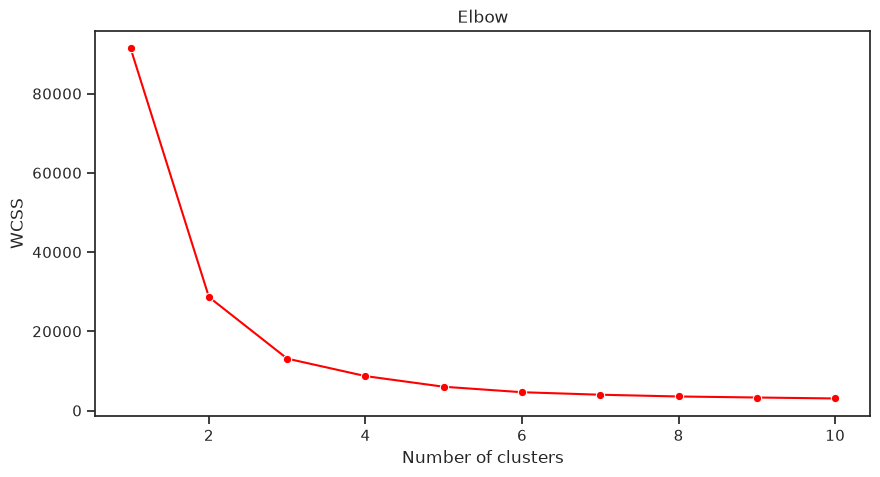

In [44]:
##Use the 'elbow method' to make sure
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.lineplot(x=range(1,11),y=wcss,marker='o',color='red')

plt.title('Elbow')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Another Example

In [45]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3)

kmeans.fit(X)
labels=kmeans.predict(X)


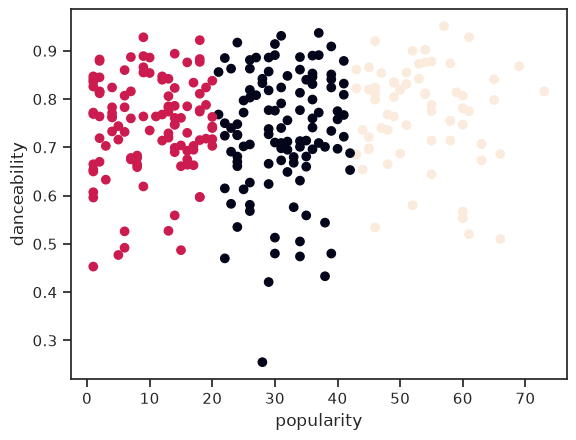

In [46]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.scatter(df['popularity'],df['danceability'],c=labels)
plt.xlabel('popularity')
plt.ylabel('danceability')
plt.show()

In [47]:
labels=kmeans.labels_

correct_labels=sum(y==labels)

print("Result: %d out of %d samples were correctly labeled."%(correct_labels,y.size))

print("Accuracy Score: {0:0.2f}".format(correct_labels/float(y.size)))

Result: 109 out of 286 samples were correctly labeled.
Accuracy Score: 0.38
